## 0. Install dependencies (run once)

In [1]:
import sys, subprocess, warnings

try:
    import xgboost
    print(f'XGBoost {xgboost.__version__}')
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', 'scikit-learn', 'pandas', 'seaborn', 'matplotlib'])

warnings.filterwarnings('ignore')
print('Done')

XGBoost 3.2.0
Done


# GlazyBench XGBoost Baseline

Predict surface finish, transparency, and color family from UMF vectors.

**Dataset:** `AlpachinoNLP/GlazyBench` (property prediction split)
**Model:** XGBoost (separate model per head)
**Validation:** 5-fold stratified cross-validation + held-out test set

In [2]:
import urllib.request
import urllib.error
import json
import os
import subprocess
import time
import warnings
from collections import Counter
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    log_loss, confusion_matrix, classification_report,
)
import xgboost as xgb

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 120

print('All imports OK')

All imports OK


---
## 1. Download and merge data

All files are downloaded from Hugging Face at runtime. No local data needed.
Total download: ~12 MB (JSON only)

In [3]:
DATA_DIR = 'data/property_prediction'
assert os.path.exists(DATA_DIR), f'Data not found at {DATA_DIR}. Upload the GlazyBench/property_prediction folder to data/'

def load_json(path):
    with open(os.path.join(DATA_DIR, path)) as f:
        return json.load(f)

train_recipes = load_json('train/recipes.json')
train_targets = load_json('train/targets.json')
test_recipes = load_json('test/recipes.json')
test_targets = load_json('test/targets.json')

print(f'Train recipes: {len(train_recipes)}  targets: {len(train_targets)}')
print(f'Test recipes:  {len(test_recipes)}  targets: {len(test_targets)}')

Train recipes: 16781  targets: 16781
Test recipes:  4903  targets: 4903


In [4]:
def merge_data(recipes, targets):
    """Join recipes and targets on 'id', flatten UMF into columns."""
    target_map = {t['id']: t for t in targets}
    rows = []
    for r in recipes:
        t = target_map.get(r['id'])
        if t is None:
            continue
        row = {'id': r['id']}
        # UMF oxides
        for ox, val in (r.get('umf') or {}).items():
            row[f'umf_{ox}'] = val
        # Cone + atmosphere
        row['cone_min'] = r.get('cone_min')
        row['cone_max'] = r.get('cone_max')
        row['atmosphere'] = r.get('atmosphere', '')
        # Targets
        row['surface'] = t.get('surface')
        row['transparency'] = t.get('transparency')
        row['color_family'] = t.get('color_family')
        rows.append(row)
    return pd.DataFrame(rows)

df_train = merge_data(train_recipes, train_targets)
df_test = merge_data(test_recipes, test_targets)

print(f'Train: {df_train.shape}  Test: {df_test.shape}')
print(f'Train cols: {list(df_train.columns)}')

Train: (16781, 25)  Test: (4903, 25)
Train cols: ['id', 'umf_Na2O', 'umf_K2O', 'umf_CaO', 'umf_MgO', 'umf_SrO', 'umf_Al2O3', 'umf_Fe2O3', 'umf_SiO2', 'cone_min', 'cone_max', 'atmosphere', 'surface', 'transparency', 'color_family', 'umf_TiO2', 'umf_B2O3', 'umf_SnO2', 'umf_ZnO', 'umf_P2O5', 'umf_Li2O', 'umf_Cr2O3', 'umf_BaO', 'umf_ZrO2', 'umf_PbO']


In [5]:
# Normalise UMF oxide columns to a union set (fill missing with 0.0)
oxide_cols_train = [c for c in df_train.columns if c.startswith('umf_')]
oxide_cols_test = [c for c in df_test.columns if c.startswith('umf_')]
all_oxides = sorted(set(oxide_cols_train) | set(oxide_cols_test))
print(f'Union oxide set ({len(all_oxides)}): {[o.replace("umf_","") for o in all_oxides]}')

for col in all_oxides:
    if col not in df_train.columns:
        df_train[col] = 0.0
    if col not in df_test.columns:
        df_test[col] = 0.0

FEATURE_COLS = all_oxides  # 8-11 oxide features
TARGET_HEADS = ['surface', 'transparency', 'color_family']

# Encode atmosphere as one-hot
for df in [df_train, df_test]:
    df['atmos_oxidation'] = (df['atmosphere'].str.lower().str.contains('oxidation', na=False)).astype(float)
    df['atmos_reduction'] = (df['atmosphere'].str.lower().str.contains('reduction', na=False)).astype(float)

FEATURE_COLS += ['atmos_oxidation', 'atmos_reduction', 'cone_min', 'cone_max']

# Clip cone outliers (2 recipes have cone_max=6004, should be ~6)
for df in [df_train, df_test]:
    df['cone_max'] = df['cone_max'].clip(upper=22)

print(f'Total features: {len(FEATURE_COLS)}')

Union oxide set (18): ['Al2O3', 'B2O3', 'BaO', 'CaO', 'Cr2O3', 'Fe2O3', 'K2O', 'Li2O', 'MgO', 'Na2O', 'P2O5', 'PbO', 'SiO2', 'SnO2', 'SrO', 'TiO2', 'ZnO', 'ZrO2']
Total features: 22


---
## 2. EDA — Label distributions

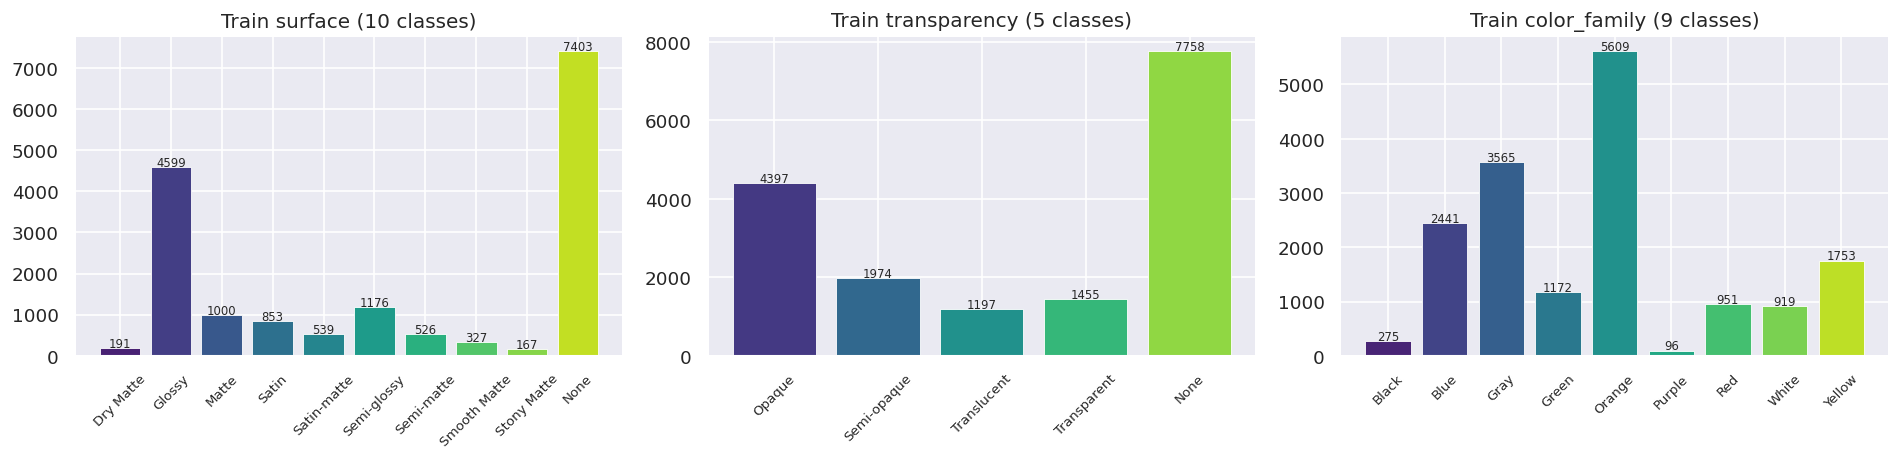

Train surface: 9378/16781 labeled (55.9%)
Train transparency: 9023/16781 labeled (53.8%)
Train color_family: 16781/16781 labeled (100.0%)


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, head in zip(axes, TARGET_HEADS):
    counts = df_train[head].value_counts(dropna=False).sort_index()
    colors = sns.color_palette('viridis', len(counts))
    ax.bar(counts.index.astype(str), counts.values, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_title(f'Train {head} ({len(counts)} classes)')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 20, str(v), ha='center', fontsize=7)
plt.tight_layout()
plt.show()

# Coverage
for head in TARGET_HEADS:
    labeled = df_train[head].notna().sum()
    print(f'Train {head}: {labeled}/{len(df_train)} labeled ({labeled/len(df_train)*100:.1f}%)')

---
## 3. Prepare feature matrices

Each head has different label coverage. We filter to labeled rows per head.

In [7]:
# Fill missing numeric features
for col in FEATURE_COLS:
    df_train[col] = df_train[col].fillna(0.0)
    df_test[col] = df_test[col].fillna(0.0)

# Build per-head datasets
datasets = {}
for head in TARGET_HEADS:
    train_mask = df_train[head].notna()
    test_mask = df_test[head].notna()
    
    le = LabelEncoder()
    y_train = le.fit_transform(df_train.loc[train_mask, head])
    y_test = le.transform(df_test.loc[test_mask, head])
    
    datasets[head] = {
        'X_train': df_train.loc[train_mask, FEATURE_COLS].values.astype(np.float32),
        'y_train': y_train,
        'X_test': df_test.loc[test_mask, FEATURE_COLS].values.astype(np.float32),
        'y_test': y_test,
        'classes': le.classes_,
        'label_encoder': le,
        'n_classes': len(le.classes_),
    }
    print(f'{head:15s}: train={len(y_train):5d}  test={len(y_test):4d}  classes={list(le.classes_)}')

surface        : train= 9378  test=3730  classes=['Dry Matte', 'Glossy', 'Matte', 'Satin', 'Satin-matte', 'Semi-glossy', 'Semi-matte', 'Smooth Matte', 'Stony Matte']
transparency   : train= 9023  test=3322  classes=['Opaque', 'Semi-opaque', 'Translucent', 'Transparent']
color_family   : train=16781  test=4903  classes=['Black', 'Blue', 'Gray', 'Green', 'Orange', 'Purple', 'Red', 'White', 'Yellow']


---
## 4. XGBoost training with 5-fold stratified CV

For each head, run 5-fold CV. Collect metrics + loss curves per fold.
Then retrain on full train set and evaluate on test.

In [8]:
XGB_PARAMS = {
    'objective': 'multi:softprob',
    'eval_metric': ['mlogloss', 'merror'],
    'learning_rate': 0.1,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42,
}
N_FOLDS = 5
N_BOOST = 500
EARLY_STOP = 30

def compute_metrics(y_true, y_pred, y_proba):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro'),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted'),
        'macro_precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'log_loss': log_loss(y_true, y_proba),
    }

In [9]:
cv_results = {}  # head -> list of per-fold metrics
cv_models = {}   # head -> list of per-fold models
cv_loss_curves = {}  # head -> {'train': [...], 'val': [...]}

for head in TARGET_HEADS:
    d = datasets[head]
    X, y = d['X_train'], d['y_train']
    
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    fold_metrics = []
    fold_models = []
    fold_loss = {'train': [], 'val': []}
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        print(f'\n--- {head} fold {fold+1}/{N_FOLDS} ---')
        
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        
        dtrain = xgb.DMatrix(X_tr, label=y_tr)
        dval = xgb.DMatrix(X_val, label=y_val)
        
        evals_result = {}
        model = xgb.train(
            {**XGB_PARAMS, 'num_class': d['n_classes']},
            dtrain,
            num_boost_round=N_BOOST,
            evals=[(dtrain, 'train'), (dval, 'val')],
            evals_result=evals_result,
            early_stopping_rounds=EARLY_STOP,
            verbose_eval=100,
        )
        
        fold_models.append(model)
        
        # Collect loss curves
        fold_loss['train'].append(evals_result['train']['mlogloss'])
        fold_loss['val'].append(evals_result['val']['mlogloss'])
        
        # Evaluate
        y_pred = model.predict(dval)
        y_pred_class = np.argmax(y_pred, axis=1)
        y_pred_proba = y_pred  # XGBoost softprob outputs probabilities
        
        metrics = compute_metrics(y_val, y_pred_class, y_pred_proba)
        fold_metrics.append(metrics)
        
        print(f'  val accuracy={metrics["accuracy"]:.4f}  macro_f1={metrics["macro_f1"]:.4f}')
    
    cv_results[head] = fold_metrics
    cv_models[head] = fold_models
    cv_loss_curves[head] = fold_loss
    
    # Aggregate
    mean_m = {k: np.mean([m[k] for m in fold_metrics]) for k in fold_metrics[0]}
    std_m = {k: np.std([m[k] for m in fold_metrics]) for k in fold_metrics[0]}
    print(f'\n{head} CV mean: ' + '  '.join(f'{k}={v:.4f}' for k, v in mean_m.items()))
    print(f'{head} CV std:  ' + '  '.join(f'{k}={v:.4f}' for k, v in std_m.items()))



--- surface fold 1/5 ---
[0]	train-mlogloss:1.60126	train-merror:0.50960	val-mlogloss:1.62103	val-merror:0.50959
[92]	train-mlogloss:0.65767	train-merror:0.17822	val-mlogloss:1.19646	val-merror:0.38539
  val accuracy=0.6146  macro_f1=0.3623

--- surface fold 2/5 ---
[0]	train-mlogloss:1.60609	train-merror:0.50960	val-mlogloss:1.61872	val-merror:0.50959
[100]	train-mlogloss:0.64003	train-merror:0.17862	val-mlogloss:1.14825	val-merror:0.36780
[200]	train-mlogloss:0.41494	train-merror:0.08838	val-mlogloss:1.12903	val-merror:0.35874
[207]	train-mlogloss:0.40311	train-merror:0.08398	val-mlogloss:1.13074	val-merror:0.35768
  val accuracy=0.6423  macro_f1=0.4364

--- surface fold 3/5 ---
[0]	train-mlogloss:1.60137	train-merror:0.50960	val-mlogloss:1.62358	val-merror:0.50959
[100]	train-mlogloss:0.62971	train-merror:0.17275	val-mlogloss:1.20153	val-merror:0.38380
[174]	train-mlogloss:0.44832	train-merror:0.10144	val-mlogloss:1.20255	val-merror:0.37527
  val accuracy=0.6247  macro_f1=0.3998

-

---
## 5. Cross-validation results table

In [10]:
print(f'{"Head":<15s} {"Accuracy":>10s} {"Macro F1":>10s} {"Wtd F1":>10s} {"Precision":>10s} {"Recall":>10s} {"Log Loss":>10s}')
print('-' * 75)

summary_rows = []
for head in TARGET_HEADS:
    metrics = cv_results[head]
    mean_m = {k: np.mean([m[k] for m in metrics]) for k in metrics[0]}
    std_m = {k: np.std([m[k] for m in metrics]) for k in metrics[0]}
    row = f'{head:<15s}'
    for k in ['accuracy', 'macro_f1', 'weighted_f1', 'macro_precision', 'macro_recall', 'log_loss']:
        row += f'  {mean_m[k]:.4f}±{std_m[k]:.4f}'
    print(row)
    summary_rows.append({'head': head, **{k: mean_m[k] for k in metrics[0]}})

print()
print(f'Average across heads:')
avg = {k: np.mean([r[k] for r in summary_rows]) for k in summary_rows[0] if k != 'head'}
print('  '.join(f'{k}={v:.4f}' for k, v in avg.items()))

Head              Accuracy   Macro F1     Wtd F1  Precision     Recall   Log Loss
---------------------------------------------------------------------------
surface          0.6257±0.0093  0.3980±0.0259  0.5835±0.0156  0.4972±0.0284  0.3637±0.0223  1.1734±0.0345
transparency     0.6603±0.0048  0.5781±0.0063  0.6424±0.0050  0.6121±0.0083  0.5673±0.0038  0.8602±0.0086
color_family     0.4064±0.0056  0.2501±0.0117  0.3596±0.0063  0.3646±0.0243  0.2361±0.0083  1.5939±0.0044

Average across heads:
accuracy=0.5641  macro_f1=0.4088  weighted_f1=0.5285  macro_precision=0.4913  macro_recall=0.3890  log_loss=1.2092


---
## 6. Loss curves (train vs val per boosting round)

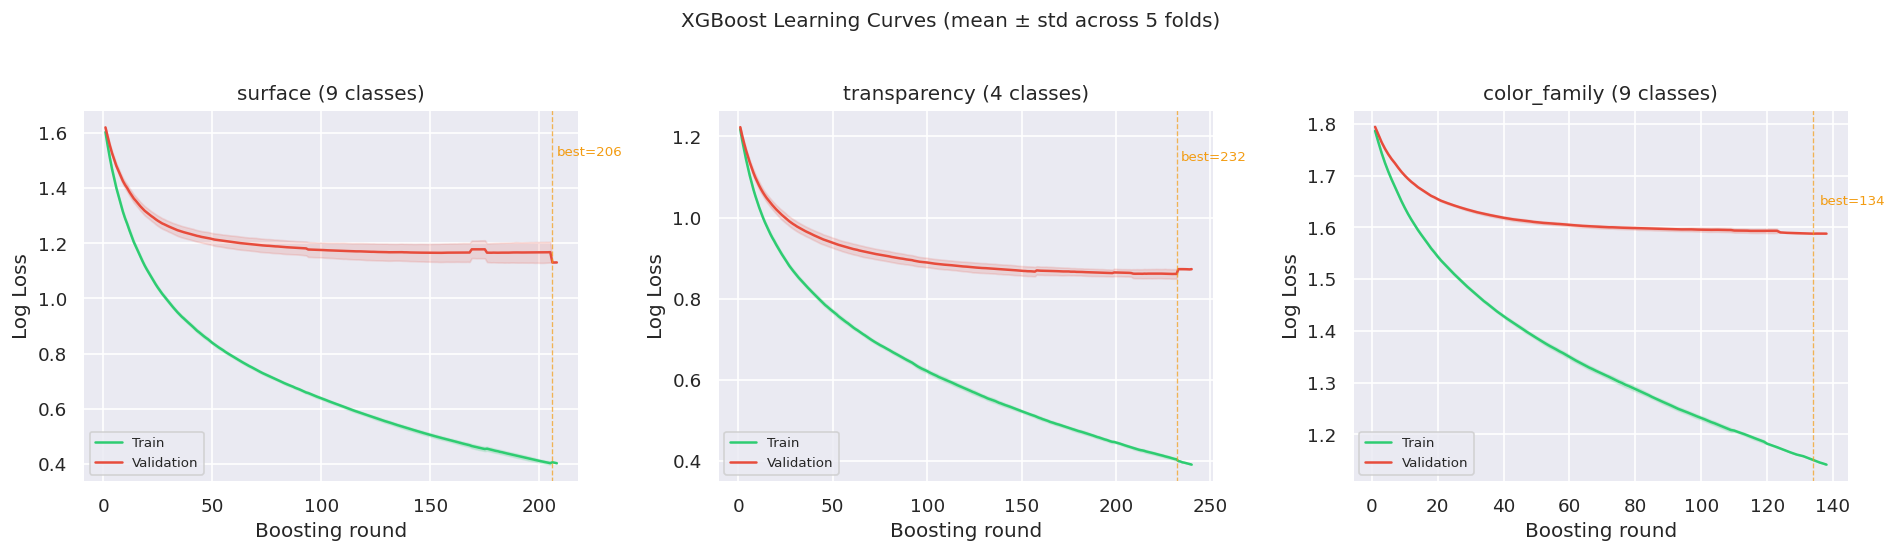

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, head in zip(axes, TARGET_HEADS):
    loss = cv_loss_curves[head]
    
    # Align lengths across folds (pad shortest with NaN for mean)
    max_len = max(len(t) for t in loss['train'])
    train_arr = np.full((N_FOLDS, max_len), np.nan)
    val_arr = np.full((N_FOLDS, max_len), np.nan)
    for i in range(N_FOLDS):
        tlen = len(loss['train'][i])
        train_arr[i, :tlen] = loss['train'][i]
        val_arr[i, :tlen] = loss['val'][i]
    
    train_mean = np.nanmean(train_arr, axis=0)
    val_mean = np.nanmean(val_arr, axis=0)
    train_std = np.nanstd(train_arr, axis=0)
    val_std = np.nanstd(val_arr, axis=0)
    
    rounds = np.arange(1, max_len + 1)
    ax.plot(rounds, train_mean, label='Train', color='#2ecc71', linewidth=1.5)
    ax.fill_between(rounds, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#2ecc71')
    ax.plot(rounds, val_mean, label='Validation', color='#e74c3c', linewidth=1.5)
    ax.fill_between(rounds, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#e74c3c')
    
    best_round = np.argmin(val_mean) + 1
    ax.axvline(best_round, color='#f39c12', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.text(best_round + 2, ax.get_ylim()[1] * 0.9, f'best={best_round}', fontsize=8, color='#f39c12')
    
    ax.set_title(f'{head} ({len(datasets[head]["classes"])} classes)')
    ax.set_xlabel('Boosting round')
    ax.set_ylabel('Log Loss')
    ax.legend(fontsize=8)

plt.suptitle('XGBoost Learning Curves (mean ± std across 5 folds)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Confusion matrices (last fold, validation set)

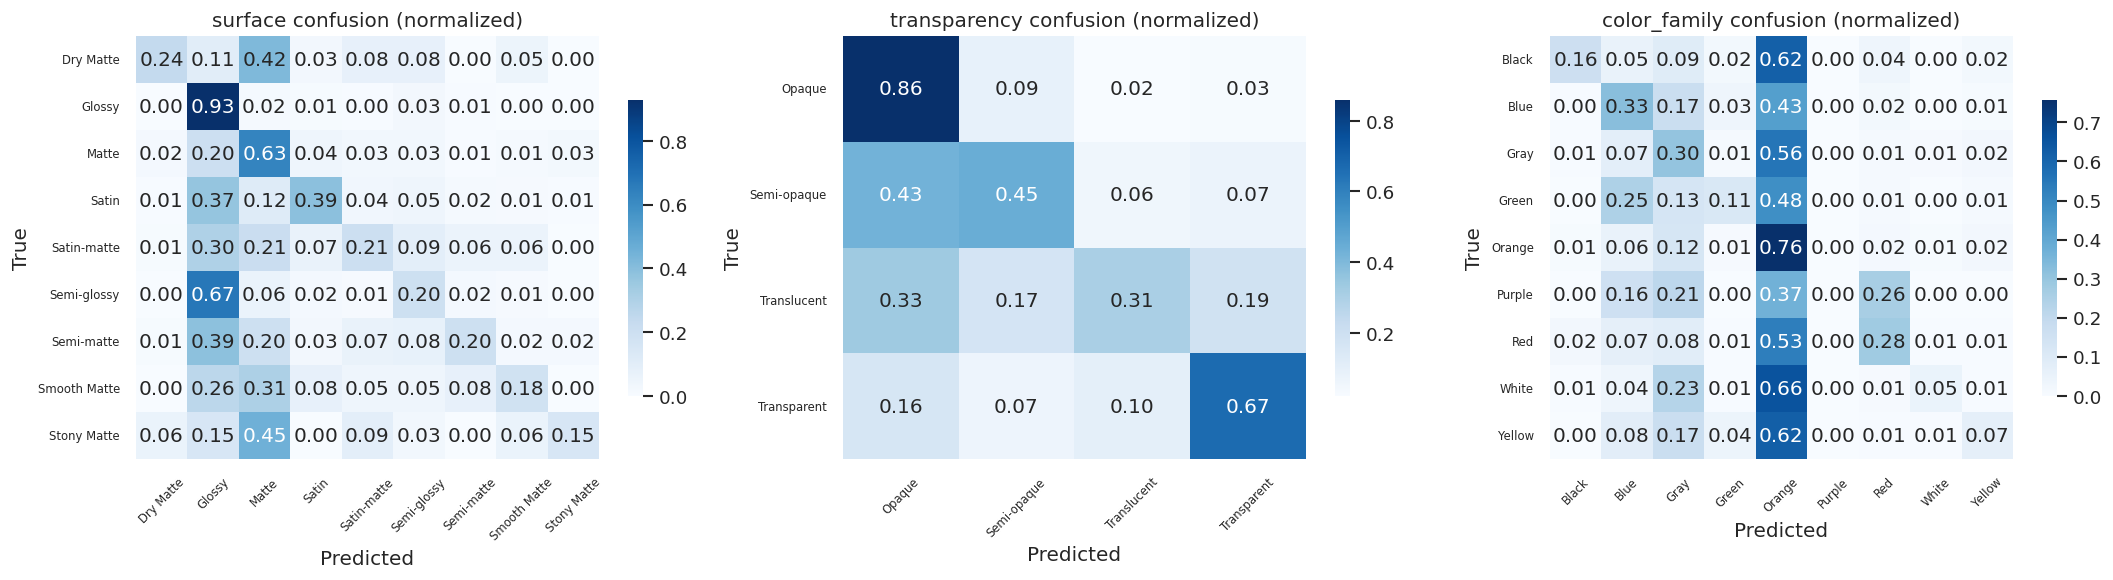

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, head in zip(axes, TARGET_HEADS):
    model = cv_models[head][-1]
    d = datasets[head]
    
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    last_train_idx, last_val_idx = list(skf.split(d['X_train'], d['y_train']))[-1]
    X_val = d['X_train'][last_val_idx]
    y_val = d['y_train'][last_val_idx]
    
    dval = xgb.DMatrix(X_val)
    y_pred = np.argmax(model.predict(dval), axis=1)
    
    cm = confusion_matrix(y_val, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    
    classes = d['classes']
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=ax, cbar_kws={'shrink': 0.7})
    ax.set_title(f'{head} confusion (normalized)')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)

plt.tight_layout()
plt.show()

---
## 8. Per-class metrics

In [13]:
for head in TARGET_HEADS:
    model = cv_models[head][-1]
    d = datasets[head]
    
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    _, val_idx = list(skf.split(d['X_train'], d['y_train']))[-1]
    X_val, y_val = d['X_train'][val_idx], d['y_train'][val_idx]
    y_pred = np.argmax(model.predict(xgb.DMatrix(X_val)), axis=1)
    
    print(f'\n=== {head} ===')
    print(classification_report(y_val, y_pred, target_names=d['classes'], digits=4))


=== surface ===
              precision    recall  f1-score   support

   Dry Matte     0.4737    0.2368    0.3158        38
      Glossy     0.7023    0.9293    0.8000       919
       Matte     0.4649    0.6300    0.5350       200
       Satin     0.6321    0.3918    0.4838       171
 Satin-matte     0.3860    0.2056    0.2683       107
 Semi-glossy     0.4196    0.1992    0.2701       236
  Semi-matte     0.4468    0.1981    0.2745       106
Smooth Matte     0.3529    0.1846    0.2424        65
 Stony Matte     0.3846    0.1515    0.2174        33

    accuracy                         0.6203      1875
   macro avg     0.4737    0.3474    0.3786      1875
weighted avg     0.5802    0.6203    0.5768      1875


=== transparency ===
              precision    recall  f1-score   support

      Opaque     0.7193    0.8601    0.7834       879
 Semi-opaque     0.5605    0.4456    0.4965       395
 Translucent     0.5069    0.3054    0.3812       239
 Transparent     0.6610    0.6701    0.

---
## 9. Feature importance (top-15 oxides per head)

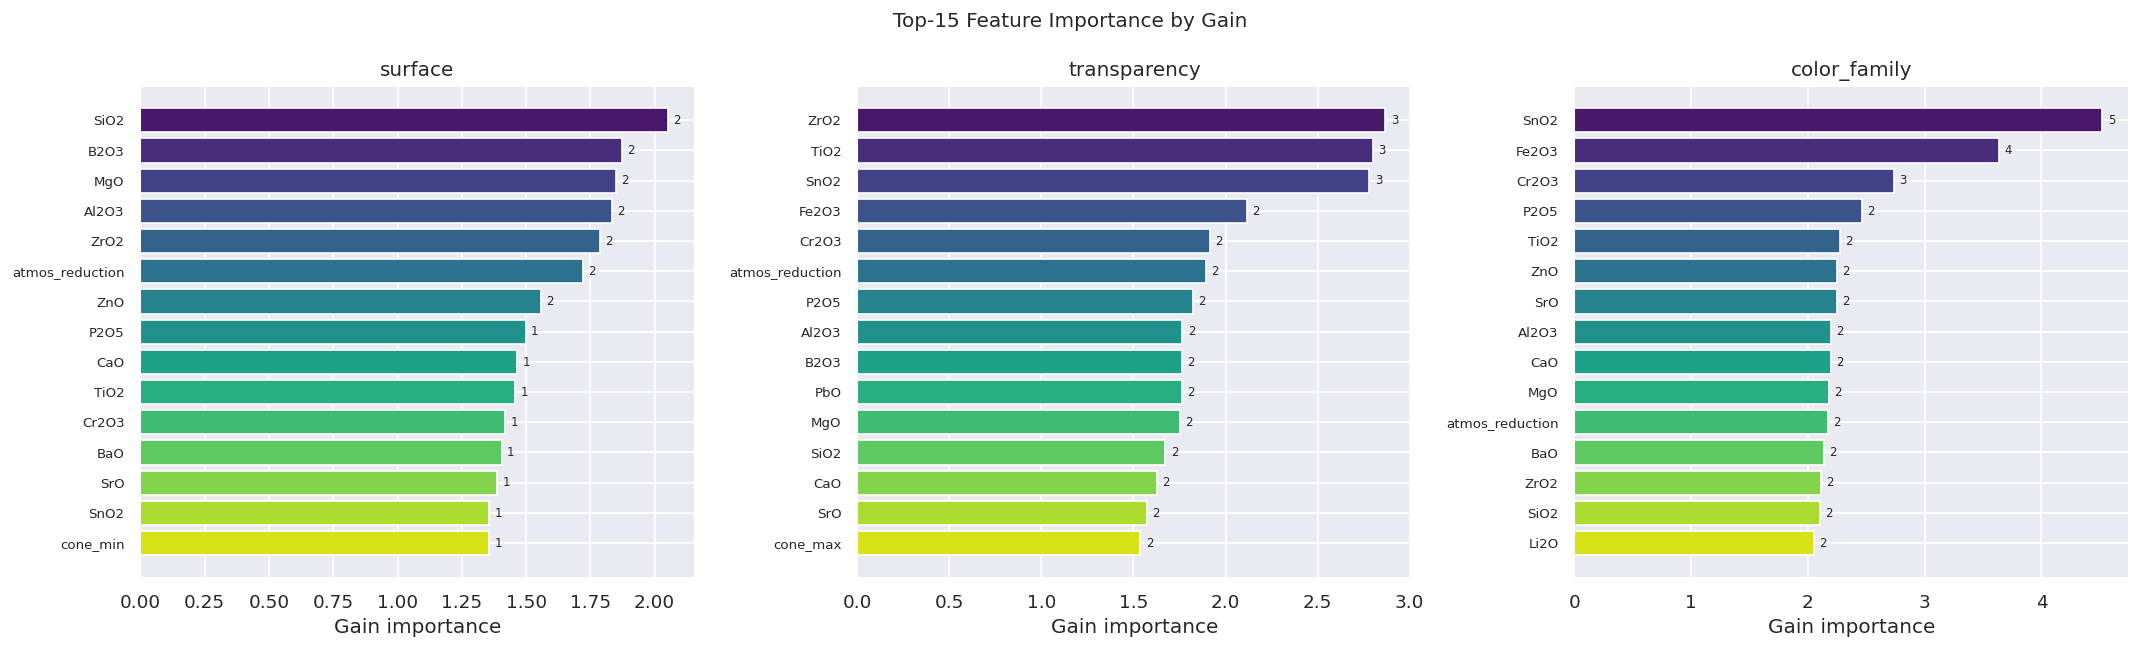

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

feature_names = [c.replace('umf_', '') for c in FEATURE_COLS]

for ax, head in zip(axes, TARGET_HEADS):
    model = cv_models[head][-1]
    importance = model.get_score(importance_type='gain')
    
    # Map f0, f1, ... to feature names
    named = {}
    for k, v in importance.items():
        idx = int(k.replace('f', ''))
        if idx < len(feature_names):
            named[feature_names[idx]] = v
    
    sorted_items = sorted(named.items(), key=lambda x: x[1], reverse=True)[:15]
    names, vals = zip(*sorted_items) if sorted_items else ([], [])
    
    bars = ax.barh(range(len(names)), vals, color=sns.color_palette('viridis', len(names)))
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('Gain importance')
    ax.set_title(f'{head}')
    for bar, v in zip(bars, vals):
        ax.text(v + max(vals) * 0.01, bar.get_y() + bar.get_height() / 2,
                f'{v:.0f}', va='center', fontsize=7)

plt.suptitle('Top-15 Feature Importance by Gain', fontsize=12)
plt.tight_layout()
plt.show()

---
## 10. Final test set evaluation

Train on full training set, evaluate on the held-out test set.
These are the numbers to report.

In [15]:
test_results = []

print(f'{"Head":<15s} {"Accuracy":>10s} {"Macro F1":>10s} {"Wtd F1":>10s} {"Precision":>10s} {"Recall":>10s} {"Log Loss":>10s}')
print('-' * 75)

for head in TARGET_HEADS:
    d = datasets[head]
    
    # Train on full train set
    dtrain = xgb.DMatrix(d['X_train'], label=d['y_train'])
    dtest = xgb.DMatrix(d['X_test'])
    
    model = xgb.train(
        {**XGB_PARAMS, 'num_class': d['n_classes']},
        dtrain,
        num_boost_round=min(N_BOOST, 150),  # fewer rounds since we have more data
        evals=[(dtrain, 'train')],  # no validation, just train
        verbose_eval=False,
    )
    
    y_proba = model.predict(dtest)
    y_pred = np.argmax(y_proba, axis=1)
    
    metrics = compute_metrics(d['y_test'], y_pred, y_proba)
    test_results.append({'head': head, **metrics})
    
    row = f'{head:<15s}'
    for k in ['accuracy', 'macro_f1', 'weighted_f1', 'macro_precision', 'macro_recall', 'log_loss']:
        row += f'  {metrics[k]:.4f}'
    print(row)

print(f'\n{"Average":<15s}')
avg = {k: np.mean([r[k] for r in test_results]) for k in test_results[0] if k != 'head'}
row = f'{"":<15s}'
for k in ['accuracy', 'macro_f1', 'weighted_f1', 'macro_precision', 'macro_recall', 'log_loss']:
    row += f'  {avg[k]:.4f}'
print(row)

Head              Accuracy   Macro F1     Wtd F1  Precision     Recall   Log Loss
---------------------------------------------------------------------------
surface          0.5491  0.2652  0.4785  0.3322  0.2605  1.3735
transparency     0.5608  0.4745  0.5242  0.5035  0.4826  1.0142
color_family     0.3388  0.2096  0.2873  0.3902  0.2066  1.7787

Average        
                 0.4829  0.3164  0.4300  0.4086  0.3165  1.3888


---
## 11. Test set confusion matrices

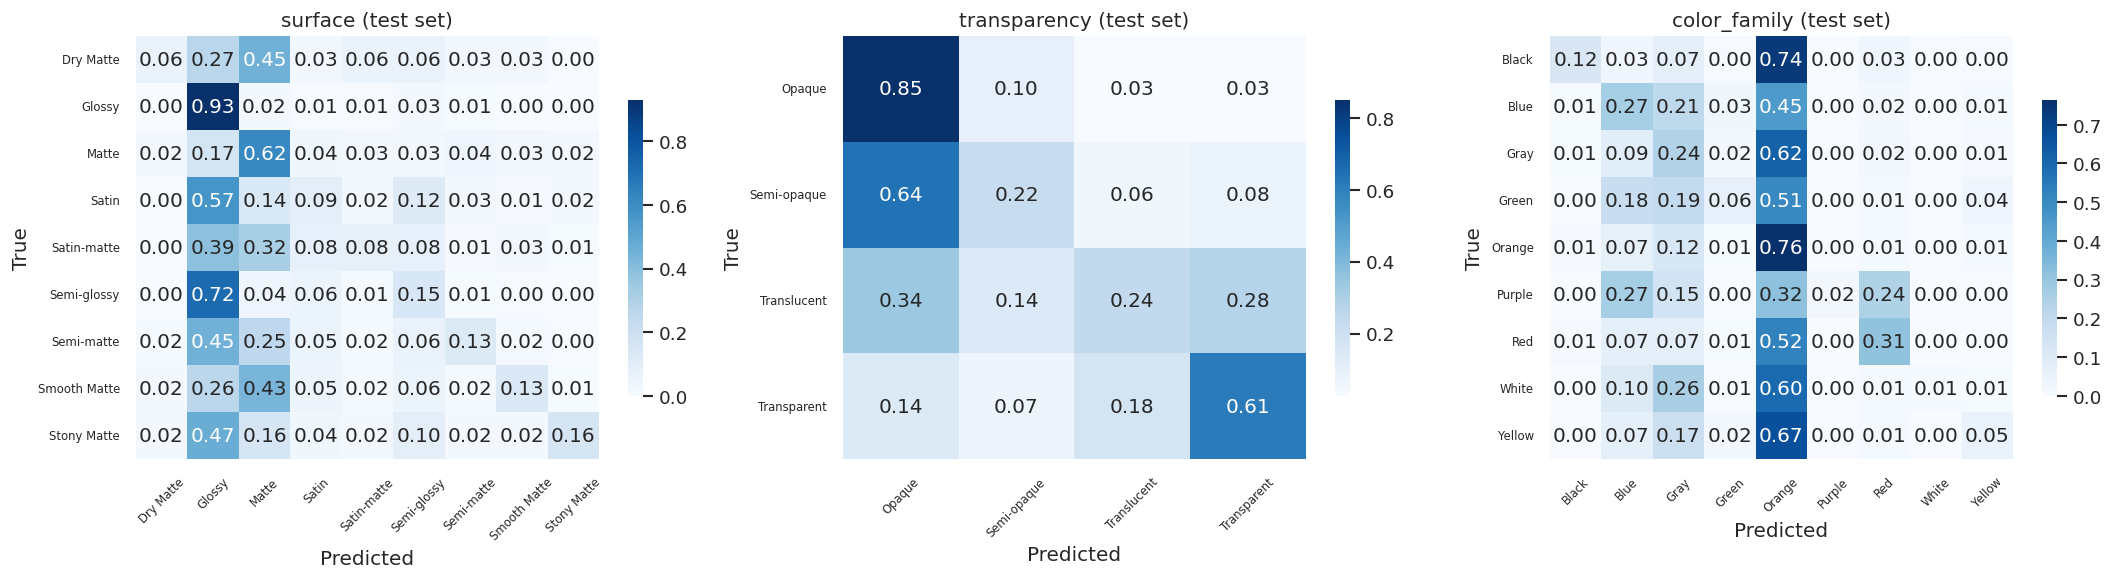

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, head in zip(axes, TARGET_HEADS):
    d = datasets[head]
    dtrain = xgb.DMatrix(d['X_train'], label=d['y_train'])
    dtest = xgb.DMatrix(d['X_test'])
    
    model = xgb.train(
        {**XGB_PARAMS, 'num_class': d['n_classes']},
        dtrain,
        num_boost_round=150,
        verbose_eval=False,
    )
    
    y_pred = np.argmax(model.predict(dtest), axis=1)
    cm = confusion_matrix(d['y_test'], y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=d['classes'], yticklabels=d['classes'], ax=ax, cbar_kws={'shrink': 0.7})
    ax.set_title(f'{head} (test set)')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)

plt.tight_layout()
plt.show()

In [17]:
# Summary

print('Test set results from section 10:')
print()
print(f'{"Head":<15s} {"Accuracy":>10s} {"Macro F1":>10s} {"Wtd F1":>10s} {"Precision":>10s} {"Recall":>10s} {"Log Loss":>10s}')
print('-' * 75)
for r in test_results:
    row = f"{r['head']:<15s}"
    for k in ['accuracy', 'macro_f1', 'weighted_f1', 'macro_precision', 'macro_recall', 'log_loss']:
        row += f'  {r[k]:.4f}'
    print(row)
print()
avg = {k: np.mean([r[k] for r in test_results]) for k in test_results[0] if k != 'head'}
print(f'{"Average":<15s}' + '  '.join(f'{avg[k]:.4f}' for k in ['accuracy', 'macro_f1', 'weighted_f1', 'macro_precision', 'macro_recall', 'log_loss']))


Test set results from section 10:

Head              Accuracy   Macro F1     Wtd F1  Precision     Recall   Log Loss
---------------------------------------------------------------------------
surface          0.5491  0.2652  0.4785  0.3322  0.2605  1.3735
transparency     0.5608  0.4745  0.5242  0.5035  0.4826  1.0142
color_family     0.3388  0.2096  0.2873  0.3902  0.2066  1.7787

Average        0.4829  0.3164  0.4300  0.4086  0.3165  1.3888
